In [90]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import json
import dit
import subprocess
from dit import Distribution
from dit.shannon import mutual_information as mi
from emergence.calc.dit import DitDistCalc
from emergence.micalc import MutualInfo
from emergence.utils.jvm import JVM
import ptitprince as pt

In [91]:
voluntary_path = "gameDumps/voluntaryvsrandom/voluntary"
random_path = "gameDumps/voluntaryvsrandom/random"
num_runs = 10

voluntary_psis = []
random_psis = []

In [93]:
# Step 1: run all the experiments (run this twice, second time after changing to random + output path)
for i in range(num_runs):
        command = "go run ."
        subprocess.run(command, shell=True)

In [94]:
# analyse using pairs scale for voluntary
for file in os.listdir(voluntary_path):
    joint_counts = {}
    total = 0
    with open(f"{voluntary_path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}
        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
              for j in range(i+1, len(agent_ids)):
                    a_id, b_id = agent_ids[i], agent_ids[j]
                    a = agent_uuid_to_idx[a_id]
                    b = agent_uuid_to_idx[b_id]
                    bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                    bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                    same_bike = int(bike_a == bike_b)
                    key = (a, b, same_bike)
                    joint_counts[key] = joint_counts.get(key, 0) + 1
                    total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=2)
    voluntary_psis.append(psi)


In [95]:
# analyse using pairs scale for random
for file in os.listdir(random_path):
    joint_counts = {}
    total = 0
    with open(f"{random_path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}
        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
              for j in range(i+1, len(agent_ids)):
                    a_id, b_id = agent_ids[i], agent_ids[j]
                    a = agent_uuid_to_idx[a_id]
                    b = agent_uuid_to_idx[b_id]
                    bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                    bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                    same_bike = int(bike_a == bike_b)
                    key = (a, b, same_bike)
                    joint_counts[key] = joint_counts.get(key, 0) + 1
                    total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=2)
    random_psis.append(psi)

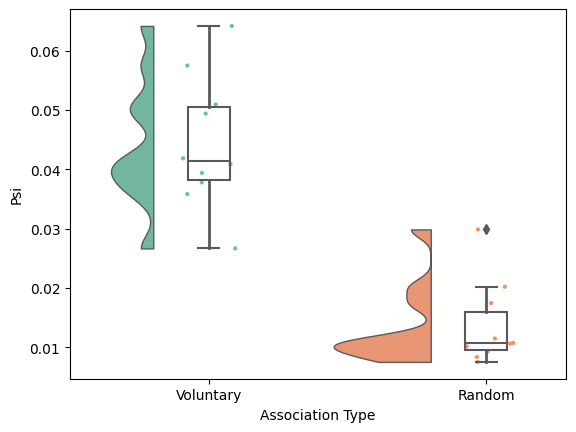

In [97]:
values = np.concatenate([voluntary_psis, random_psis])
groups = (["Voluntary"] * num_runs +
          ["Random"] * num_runs)

df = pd.DataFrame({
    "Psi": values,
    "Association Type": groups
})

# Assuming df is already created as you showed
ax = pt.RainCloud(x="Association Type", y="Psi", data=df, orient="v")

In [89]:
# Step 4: Cleanup
for file in os.listdir(voluntary_path):
     os.remove(f"{voluntary_path}/{file}")

for file in os.listdir(random_path):
     os.remove(f"{random_path}/{file}")